# Chapter 256 — Monte Carlo Methods
### Part VIII: Probability

Monte Carlo methods replace analytical computation with randomness. When an integral is too hard to evaluate, a distribution too complex to sample from directly, or a system too entangled to solve symbolically — you simulate it. This is not a fallback. It is a primary tool in statistics, physics, finance, and machine learning.

The name comes from the Monte Carlo Casino in Monaco. Stanislaw Ulam, working on neutron diffusion problems for the Manhattan Project, recognized that random sampling could solve problems that resisted pen-and-paper analysis. The method has since become foundational.

**Prerequisites:** Law of Large Numbers (ch255), Expected Value (ch249), Integration intuition (ch221 — Numerical Integration), Variance (ch250).

## 1. The Core Idea

Monte Carlo estimation rests on the Law of Large Numbers *(ch255)*:

$$\frac{1}{N} \sum_{i=1}^{N} f(X_i) \xrightarrow{N \to \infty} \mathbb{E}[f(X)]$$

If we want to compute $\mathbb{E}[f(X)]$ and we can sample $X_i \sim p(x)$, we just average $f(X_i)$ over many samples.

**Integration connection:** The integral $\int_a^b f(x)\,dx = (b-a)\,\mathbb{E}[f(U)]$ where $U \sim \text{Uniform}(a,b)$. So integration becomes expectation estimation.

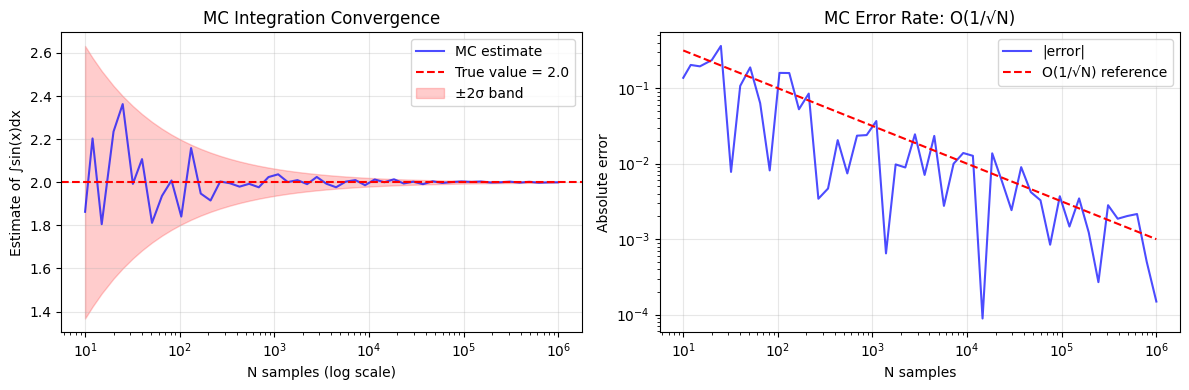

At N=1,000,000: estimate=1.999851, error=0.000149


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

rng = np.random.default_rng(42)

# MC integration of sin(x) from 0 to pi — exact answer is 2.0
a, b = 0, np.pi
true_value = 2.0

ns = np.logspace(1, 6, 50).astype(int)
estimates = []
errors = []

for n in ns:
    x = rng.uniform(a, b, n)
    est = (b - a) * np.mean(np.sin(x))
    estimates.append(est)
    errors.append(abs(est - true_value))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogx(ns, estimates, 'b-', alpha=0.7, label='MC estimate')
axes[0].axhline(true_value, color='red', linestyle='--', label=f'True value = {true_value}')
axes[0].fill_between(ns,
    [true_value - 2/np.sqrt(n) for n in ns],
    [true_value + 2/np.sqrt(n) for n in ns],
    alpha=0.2, color='red', label='±2σ band')
axes[0].set_xlabel('N samples (log scale)')
axes[0].set_ylabel('Estimate of ∫sin(x)dx')
axes[0].set_title('MC Integration Convergence')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].loglog(ns, errors, 'b-', alpha=0.7, label='|error|')
axes[1].loglog(ns, 1/np.sqrt(ns), 'r--', label='O(1/√N) reference')
axes[1].set_xlabel('N samples')
axes[1].set_ylabel('Absolute error')
axes[1].set_title('MC Error Rate: O(1/√N)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mc_integration_convergence.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"At N=1,000,000: estimate={estimates[-1]:.6f}, error={errors[-1]:.6f}")

## 2. Error Analysis and the Monte Carlo Rate

The MC estimator $\hat{\mu}_N = \frac{1}{N}\sum f(X_i)$ has:
- **Bias:** zero (it's an unbiased estimator of $\mathbb{E}[f(X)]$)
- **Variance:** $\text{Var}(\hat{\mu}_N) = \frac{\text{Var}(f(X))}{N}$
- **Standard error:** $\text{SE} = \frac{\sigma_{f}}{\sqrt{N}}$

This $O(1/\sqrt{N})$ rate is **dimension-independent** — the key advantage over deterministic quadrature in high dimensions, where grid-based methods scale as $O(h^p)$ with $h = N^{-1/d}$ points in $d$ dimensions.

For $d=10$, getting error $0.01$ with a 5th-order rule requires $10^{10^{5/10}} = 10^{10}$ points. MC needs $10^4$ regardless of $d$.

In [2]:
# MC confidence intervals — the right way to report MC results
def mc_estimate_with_ci(f, sampler, n_samples, confidence=0.95):
    """Estimate E[f(X)] with a confidence interval.
    
    Args:
        f: function to evaluate
        sampler: callable returning n_samples samples from the distribution
        n_samples: number of samples
        confidence: confidence level (default 0.95)
    
    Returns:
        dict with estimate, std_error, ci_low, ci_high
    """
    samples = sampler(n_samples)
    values = f(samples)
    
    mean = np.mean(values)
    std = np.std(values, ddof=1)  # Bessel correction (ch250)
    se = std / np.sqrt(n_samples)
    
    z = stats.norm.ppf((1 + confidence) / 2)  # e.g., 1.96 for 95%
    ci_low = mean - z * se
    ci_high = mean + z * se
    
    return {
        'estimate': mean,
        'std_error': se,
        'ci_low': ci_low,
        'ci_high': ci_high,
        'width': ci_high - ci_low
    }

# Example: estimate E[X^2] where X ~ Uniform(0, 1). True value = 1/3
result = mc_estimate_with_ci(
    f=lambda x: x**2,
    sampler=lambda n: rng.uniform(0, 1, n),
    n_samples=100_000
)

print("Estimating E[X²] for X ~ Uniform(0,1)")
print(f"True value:     {1/3:.6f}")
print(f"MC estimate:    {result['estimate']:.6f}")
print(f"Std error:      {result['std_error']:.6f}")
print(f"95% CI:         [{result['ci_low']:.6f}, {result['ci_high']:.6f}]")
print(f"CI width:       {result['width']:.6f}")
print(f"True in CI?     {result['ci_low'] <= 1/3 <= result['ci_high']}")

Estimating E[X²] for X ~ Uniform(0,1)
True value:     0.333333
MC estimate:    0.333869
Std error:      0.000944
95% CI:         [0.332019, 0.335719]
CI width:       0.003700
True in CI?     True


## 3. Importance Sampling

Standard MC draws from the proposal $p(x)$ uniformly. But if $f(x)p(x)$ is concentrated in a small region, most samples contribute nothing. **Importance sampling** draws from a better proposal $q(x)$ and corrects:

$$\mathbb{E}_p[f(X)] = \int f(x)\frac{p(x)}{q(x)} q(x)\,dx = \mathbb{E}_q\left[f(X)\frac{p(X)}{q(X)}\right]$$

The ratio $w(x) = p(x)/q(x)$ is the **importance weight**. A good $q$ concentrates mass where $|f(x)|p(x)$ is large.

In [3]:
# Importance sampling: estimate P(X > 4) for X ~ N(0,1)
# True value: 1 - Phi(4) ≈ 3.167e-5  (rare event)
# Naive MC needs ~1/3e-5 ≈ 30,000 samples just to see ONE event

true_prob = 1 - stats.norm.cdf(4)
print(f"True P(X > 4) = {true_prob:.6e}")

N = 100_000

# Naive MC
x_naive = rng.standard_normal(N)
naive_est = np.mean(x_naive > 4)
naive_se = np.sqrt(naive_est * (1 - naive_est) / N) if naive_est > 0 else float('inf')
print(f"\nNaive MC (N={N:,}):")
print(f"  Estimate: {naive_est:.6e}  (SE: {naive_se:.2e})")
print(f"  Nonzero samples: {int(naive_est * N)}")

# Importance sampling: propose from N(4, 1) — centered on the rare region
mu_q = 4.0
x_is = rng.normal(mu_q, 1.0, N)

# Only keep x > 4 (indicator function)
indicator = (x_is > 4).astype(float)

# Importance weights: p(x)/q(x)
log_p = stats.norm.logpdf(x_is, 0, 1)  # target: N(0,1)
log_q = stats.norm.logpdf(x_is, mu_q, 1)  # proposal: N(4,1)
weights = np.exp(log_p - log_q)

is_est = np.mean(indicator * weights)
is_se = np.std(indicator * weights, ddof=1) / np.sqrt(N)

print(f"\nImportance Sampling (N={N:,}, proposal=N(4,1)):")
print(f"  Estimate: {is_est:.6e}  (SE: {is_se:.2e})")
print(f"  Relative error: {abs(is_est - true_prob)/true_prob:.4f}")
print(f"  Variance reduction: {(naive_se/is_se):.1f}x" if naive_se > 0 else "  Naive SE undefined (zero estimate)")

True P(X > 4) = 3.167124e-05

Naive MC (N=100,000):
  Estimate: 3.000000e-05  (SE: 1.73e-05)
  Nonzero samples: 3

Importance Sampling (N=100,000, proposal=N(4,1)):
  Estimate: 3.168492e-05  (SE: 2.13e-07)
  Relative error: 0.0004
  Variance reduction: 81.5x


## 4. Monte Carlo for High-Dimensional Integrals

In $d$ dimensions, MC shines. The unit hypercube $[0,1]^d$ has volume 1. The unit hypersphere in $d$ dimensions has volume $V_d = \pi^{d/2} / \Gamma(d/2 + 1)$. We estimate $V_d$ via MC.

In [4]:
from scipy.special import gamma

def hypersphere_volume_true(d):
    """True volume of unit hypersphere in d dimensions."""
    return np.pi**(d/2) / gamma(d/2 + 1)

def hypersphere_volume_mc(d, n_samples=500_000, rng_state=None):
    """MC estimate: fraction of hypercube points inside hypersphere.
    Hypercube [-1,1]^d has volume 2^d.
    """
    if rng_state is None:
        rng_state = np.random.default_rng(42)
    x = rng_state.uniform(-1, 1, (n_samples, d))
    inside = np.sum(x**2, axis=1) <= 1.0
    fraction = np.mean(inside)
    volume_estimate = fraction * (2**d)
    se = np.sqrt(fraction * (1 - fraction) / n_samples) * (2**d)
    return volume_estimate, se

dimensions = [1, 2, 3, 4, 5, 6, 8, 10]
print(f"{'d':>4} {'True V_d':>12} {'MC Estimate':>12} {'Rel Error':>10} {'SE':>10}")
print("-" * 55)

local_rng = np.random.default_rng(0)
for d in dimensions:
    true_v = hypersphere_volume_true(d)
    mc_v, se = hypersphere_volume_mc(d, n_samples=500_000, rng_state=local_rng)
    rel_err = abs(mc_v - true_v) / true_v
    print(f"{d:>4} {true_v:>12.6f} {mc_v:>12.6f} {rel_err:>10.4f} {se:>10.6f}")

   d     True V_d  MC Estimate  Rel Error         SE
-------------------------------------------------------
   1     2.000000     2.000000     0.0000   0.000000
   2     3.141593     3.139608     0.0006   0.002324
   3     4.188790     4.198112     0.0022   0.005650
   4     4.934802     4.950720     0.0032   0.010460
   5     5.263789     5.248000     0.0030   0.016757
   6     5.167713     5.182464     0.0029   0.024691
   8     4.058712     3.974656     0.0207   0.044760
  10     2.550164     2.625536     0.0296   0.073235


## 5. Variance Reduction: Control Variates

A **control variate** is a function $g(X)$ with known mean $\mu_g = \mathbb{E}[g(X)]$, correlated with $f(X)$. The estimator:

$$\hat{\mu}_{CV} = \frac{1}{N}\sum [f(X_i) - c(g(X_i) - \mu_g)]$$

is still unbiased (the correction has zero mean) but has lower variance when $c$ is chosen optimally: $c^* = \text{Cov}(f,g)/\text{Var}(g)$.

Estimating E[e^X], X ~ Uniform(0,1)
True value:         1.718282
Naive mean:         1.718253
CV mean:            1.718286
Naive variance:     0.00002429
CV variance:        0.00000036
Variance reduction: 66.7x


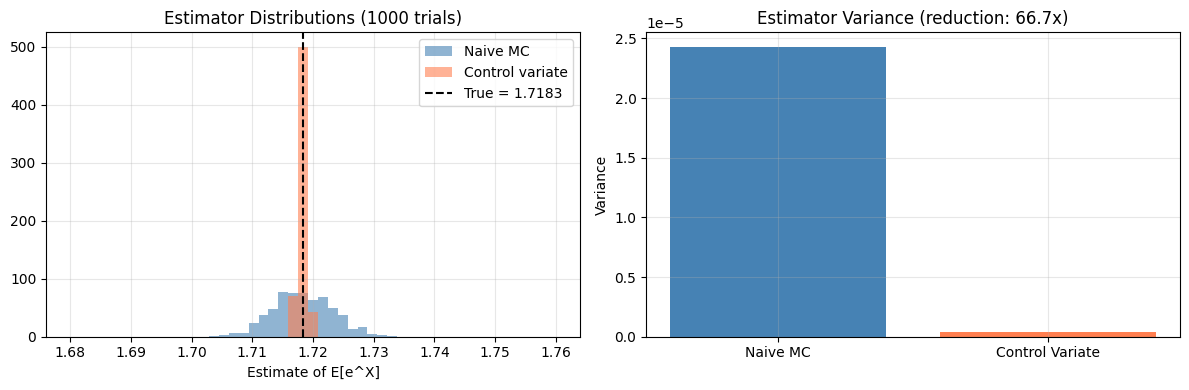

In [5]:
# Estimate E[e^X] for X ~ Uniform(0,1)
# True value: e^1 - e^0 = e - 1 ≈ 1.71828
# Control variate: g(X) = X, E[X] = 0.5, strongly correlated with e^X

true_value = np.e - 1
N = 10_000
n_trials = 1000

naive_estimates = []
cv_estimates = []

for _ in range(n_trials):
    x = rng.uniform(0, 1, N)
    f_vals = np.exp(x)         # function of interest
    g_vals = x                  # control variate
    mu_g = 0.5                  # E[g(X)] = E[X] = 0.5
    
    # Naive estimate
    naive_estimates.append(np.mean(f_vals))
    
    # Optimal coefficient (estimated from same samples)
    c_star = np.cov(f_vals, g_vals)[0, 1] / np.var(g_vals, ddof=1)
    cv_est = np.mean(f_vals - c_star * (g_vals - mu_g))
    cv_estimates.append(cv_est)

naive_var = np.var(naive_estimates)
cv_var = np.var(cv_estimates)

print(f"Estimating E[e^X], X ~ Uniform(0,1)")
print(f"True value:         {true_value:.6f}")
print(f"Naive mean:         {np.mean(naive_estimates):.6f}")
print(f"CV mean:            {np.mean(cv_estimates):.6f}")
print(f"Naive variance:     {naive_var:.8f}")
print(f"CV variance:        {cv_var:.8f}")
print(f"Variance reduction: {naive_var/cv_var:.1f}x")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bins = np.linspace(1.68, 1.76, 50)
axes[0].hist(naive_estimates, bins=bins, alpha=0.6, color='steelblue', label='Naive MC', density=True)
axes[0].hist(cv_estimates, bins=bins, alpha=0.6, color='coral', label='Control variate', density=True)
axes[0].axvline(true_value, color='black', linestyle='--', label=f'True = {true_value:.4f}')
axes[0].set_title('Estimator Distributions (1000 trials)')
axes[0].set_xlabel('Estimate of E[e^X]')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(['Naive MC', 'Control Variate'], [naive_var, cv_var], color=['steelblue', 'coral'])
axes[1].set_title(f'Estimator Variance (reduction: {naive_var/cv_var:.1f}x)')
axes[1].set_ylabel('Variance')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mc_control_variates.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Summary

| Technique | When to use | Key property |
|-----------|------------|-------------|
| Naive MC | Simple expectations/integrals | Unbiased, O(1/√N) error |
| Importance Sampling | Rare events, concentrated integrand | Reduces variance by focusing samples |
| Control Variates | When a correlated g(X) with known mean exists | Can dramatically reduce variance |

Monte Carlo is not approximate — given enough samples, it converges to the truth. The rate $O(1/\sqrt{N})$ is often the bottleneck, which is why variance reduction matters.

## 9. Forward References

- **ch257 — Markov Chains**: MCMC (Markov Chain Monte Carlo) extends MC to cases where you cannot sample $p(x)$ directly but can construct a chain that converges to it.
- **ch260 — Project: Monte Carlo π**: The canonical first MC application, using geometric probability.
- **ch275 — Hypothesis Testing** *(Part IX)*: Permutation tests are MC-based hypothesis tests — shuffle labels, recompute statistic, estimate the null distribution.